<a href="https://colab.research.google.com/github/rahulkeshamoni129/-Development-of-Interactive-Cyber-Threat-Visualization-Dashboard-/blob/main/python_DataAnalysis_infosys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python Data Analysis

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression


In [34]:
import numpy as np
import pandas as pd

np.random.seed(42)

rows = 1500

cyber_data = pd.DataFrame({
    "incident_id": range(1, rows + 1),
    "attack_type": np.random.choice(
        [
            "Phishing", "Malware", "DDoS", "Ransomware",
            "SQL Injection", "Brute Force", "XSS", "Trojan"
        ],
        rows
    ),
    "severity": np.random.choice(
        ["Low", "Medium", "High", "Critical"],
        rows,
        p=[0.35, 0.30, 0.25, 0.10]
    ),
    "system_id": np.random.randint(101, 121, rows),
    "country": np.random.choice(
        [
            "India", "USA", "UK", "Germany", "France",
            "China", "Russia", "Brazil", "Canada", "Australia"
        ],
        rows
    ),
    "date": pd.to_datetime("2023-01-01") +
            pd.to_timedelta(
                np.random.randint(0, 600, rows),
                unit="D"
            )
})

# Introduce missing values
missing_attack = np.random.choice(cyber_data.index, int(rows * 0.05), replace=False)
missing_severity = np.random.choice(cyber_data.index, int(rows * 0.03), replace=False)
missing_country = np.random.choice(cyber_data.index, int(rows * 0.02), replace=False)

cyber_data.loc[missing_attack, "attack_type"] = np.nan
cyber_data.loc[missing_severity, "severity"] = np.nan
cyber_data.loc[missing_country, "country"] = np.nan

# Add duplicate rows (for data cleaning practice)
cyber_data = pd.concat(
    [cyber_data, cyber_data.sample(20, random_state=42)],
    ignore_index=True
)

# Save dataset
cyber_data.to_csv("cyber_threat_dataset.csv", index=False)

cyber_data.head()


,incident_id,attack_type,severity,system_id,country,date
0,1,XSS,Low,109,USA,2023-10-18
1,2,NaN,Critical,109,Germany,2024-04-29
2,3,SQL Injection,Medium,104,USA,2023-11-02
3,4,XSS,Low,103,NaN,2023-05-08
4,5,DDoS,Low,117,Russia,2023-09-30


Data Collection Prompt

In [35]:
# Collect data by loading dataset
df = pd.read_csv("cyber_threat_dataset.csv")
df.head()


,incident_id,attack_type,severity,system_id,country,date
0,1,XSS,Low,109,USA,2023-10-18
1,2,NaN,Critical,109,Germany,2024-04-29
2,3,SQL Injection,Medium,104,USA,2023-11-02
3,4,XSS,Low,103,NaN,2023-05-08
4,5,DDoS,Low,117,Russia,2023-09-30


Data Cleaning Prompt

In [36]:
# Check missing values
n=df.isnull().sum()
print(n)


# Remove duplicates if any
df = df.drop_duplicates()


incident_id     0
attack_type    76
severity       47
system_id       0
country        31
date            0
dtype: int64


Data Transformation Prompt

In [37]:
# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Encode categorical columns
encoder = LabelEncoder()
df['attack_type_enc'] = encoder.fit_transform(df['attack_type'].fillna('Unknown')) # Handle NaN
df['severity_enc'] = encoder.fit_transform(df['severity'].fillna('Unknown')) # Handle NaN

Exploratory Data Analysis (EDA) Prompt

In [38]:
# Basic dataset overview
df.info()

# Severity distribution
df['severity'].value_counts()

<class 'pandas.core.frame.DataFrame'>
Index: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   incident_id      1500 non-null   int64         
 1   attack_type      1425 non-null   object        
 2   severity         1455 non-null   object        
 3   system_id        1500 non-null   int64         
 4   country          1470 non-null   object        
 5   date             1500 non-null   datetime64[ns]
 6   attack_type_enc  1500 non-null   int64         
 7   severity_enc     1500 non-null   int64         
dtypes: datetime64[ns](1), int64(4), object(3)
memory usage: 105.5+ KB


,count
severity,
Low,506
Medium,418
High,392
Critical,139


Data Visualization Prompt

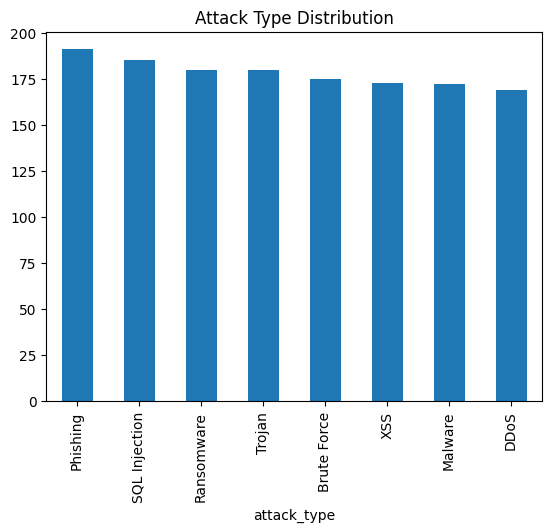

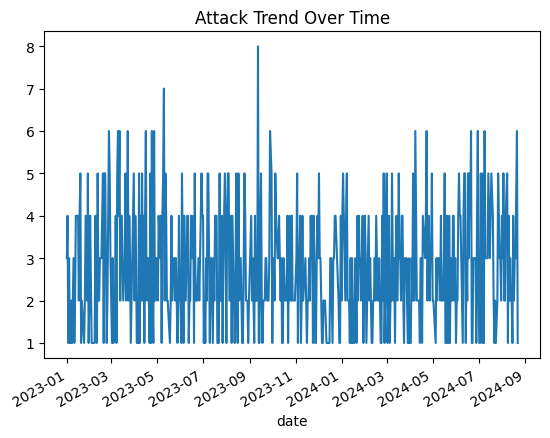

In [39]:
# Attack type distribution
df['attack_type'].value_counts().plot(kind='bar', title='Attack Type Distribution')
plt.show()

# Time-based trend
df.groupby('date').size().plot(title='Attack Trend Over Time')
plt.show()



#### Monthly Incident Trends

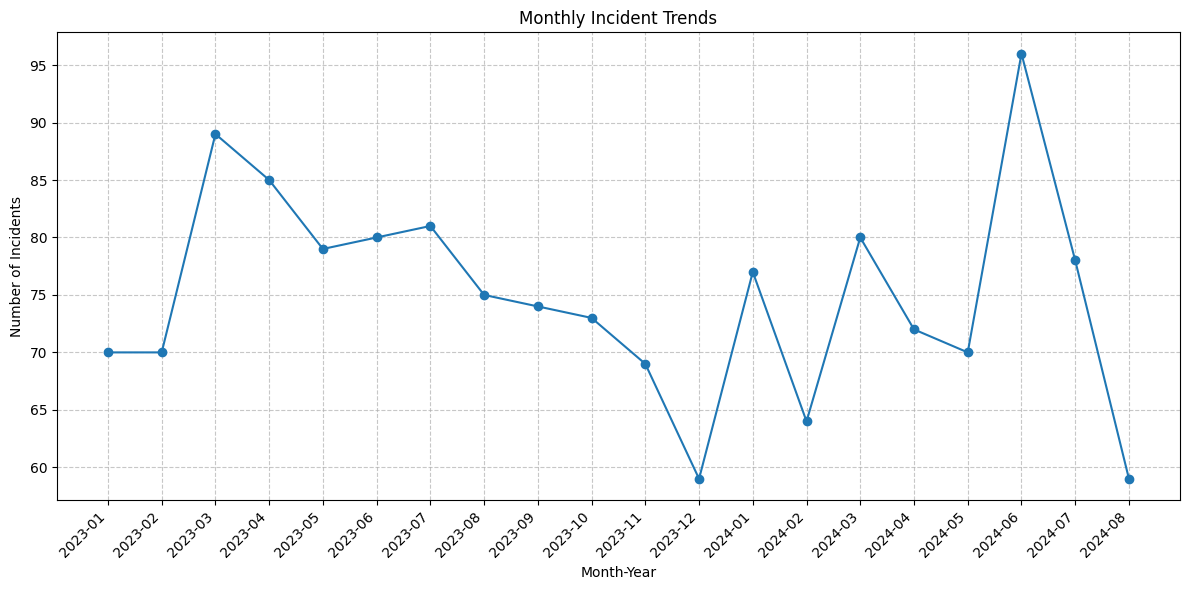

In [40]:
# Extract month and year for time-series aggregation
df['year_month'] = df['date'].dt.to_period('M')

monthly_incidents = df.groupby('year_month').size().reset_index(name='incident_count')
monthly_incidents['year_month'] = monthly_incidents['year_month'].astype(str) # Convert Period to string for plotting

plt.figure(figsize=(12, 6))
plt.plot(monthly_incidents['year_month'], monthly_incidents['incident_count'], marker='o')
plt.title('Monthly Incident Trends')
plt.xlabel('Month-Year')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Top Countries by High-Risk Incidents

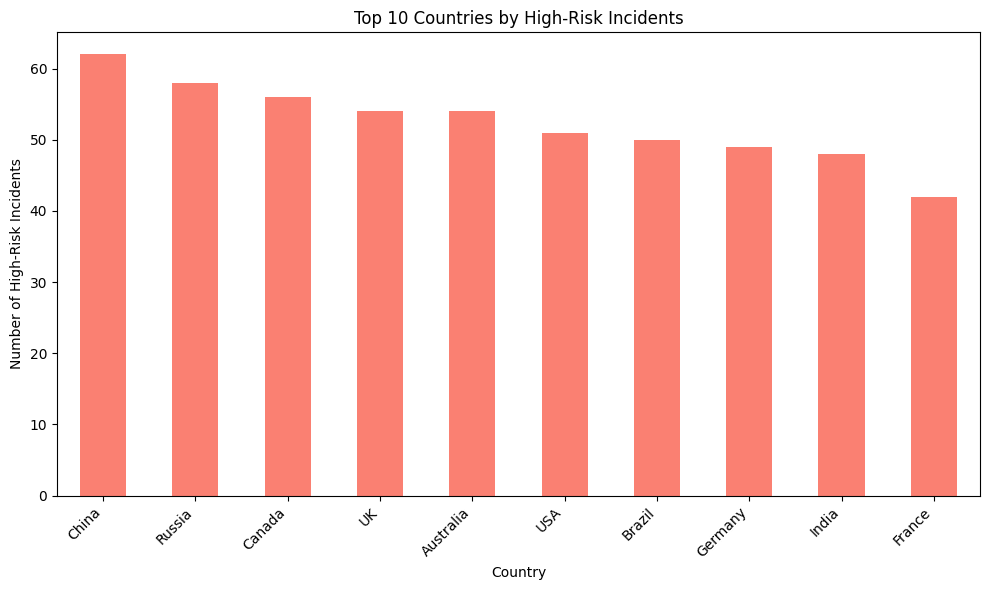

In [43]:
# Filter for high-risk incidents
high_risk_df = df[df['high_risk'] == 1]

# Group by country and count high-risk incidents
country_high_risk = high_risk_df['country'].value_counts().head(10)

plt.figure(figsize=(10, 6))
country_high_risk.plot(kind='bar', color='salmon')
plt.title('Top 10 Countries by High-Risk Incidents')
plt.xlabel('Country')
plt.ylabel('Number of High-Risk Incidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Incident Frequency per System ID

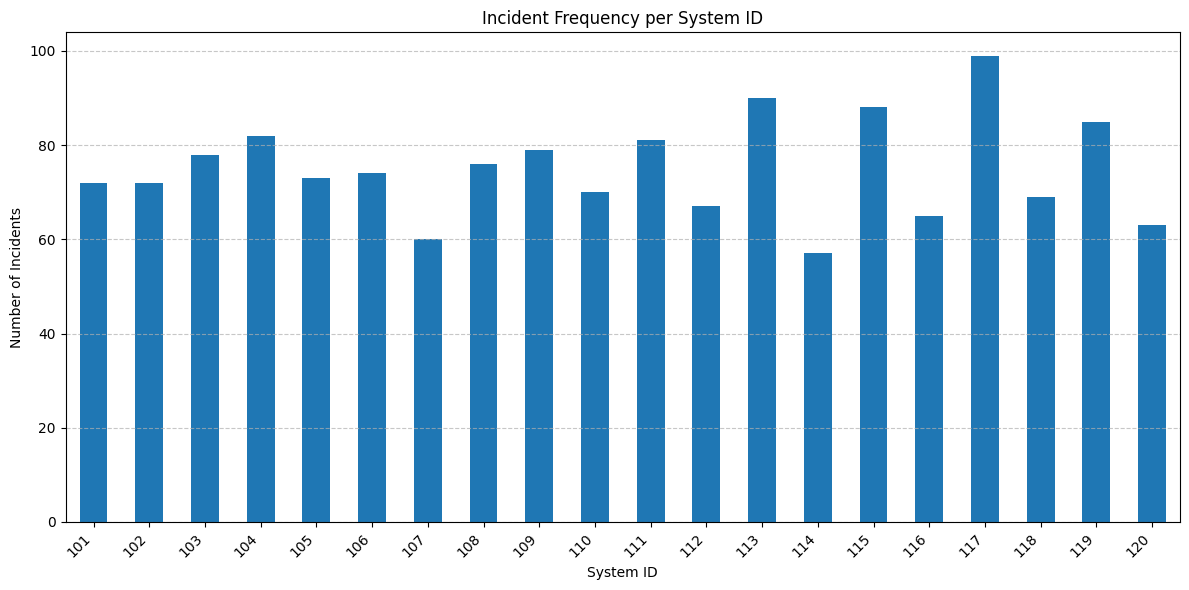

In [44]:
# Count incidents per system ID
system_incident_counts = df['system_id'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
system_incident_counts.plot(kind='bar')
plt.title('Incident Frequency per System ID')
plt.xlabel('System ID')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

 Statistical Analysis Prompt

In [45]:
# Descriptive statistics
df.describe()

# Average attacks per system
df.groupby('system_id').size().mean()

np.float64(75.0)

Modeling & Prediction Prompt

In [46]:
# Simple classification: predict high risk (High/Critical)
df['high_risk'] = df['severity'].isin(['High', 'Critical']).astype(int)

# Features and target
X = df[['attack_type_enc']]
y = df['high_risk']

# Train model
model = LogisticRegression()
model.fit(X, y)

# Prediction sample
model.predict(X.head())

array([0, 0, 0, 0, 0])

Interpretation and Reporting Prompt

In [47]:
print("Total incidents:", len(df))
print("High risk incidents:", df['high_risk'].sum())
print("Most common attack type:", df['attack_type'].value_counts().idxmax())

Total incidents: 1500
High risk incidents: 531
Most common attack type: Phishing
